In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False

In [ ]:
df = pd.read_csv('data\california.csv')
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0


In [ ]:
df.shape

(17000, 9)

In [ ]:
# 결측치를 랜덤하게 생성하기
df_missing = df.copy()  # 데이터 프레임의 복사본 만들기
missing_count = 20  # 만들 결측치 개수

# 랜덤결과를 동일하게 만들기 위한 랜덤 생성자 만들기
rng = np.random.default_rng(42)

rows = rng.integers(0, df.shape[0], size=missing_count)
cols = rng.integers(0, df.shape[1], size=missing_count)

print(rows)
print(cols)

[ 1517 13157 11127  7460  7361 14596  1461 11855  3424  1601  8950 16585
 12507 12939 12197 13363  8724  2177 14275  7656]
[4 3 1 8 7 5 3 7 4 3 4 2 0 4 7 0 7 7 2 5]


In [ ]:
# 랜덤한 셀에 NaN을 대입

for i in range(missing_count):
    df_missing.iloc[rows[i], cols[i]] = np.nan
    
#

In [ ]:
df_missing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16998 non-null  float64
 1   latitude            16999 non-null  float64
 2   housing_median_age  16998 non-null  float64
 3   total_rooms         16997 non-null  float64
 4   total_bedrooms      16996 non-null  float64
 5   population          16998 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       16995 non-null  float64
 8   median_house_value  16999 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
df_missing.isna()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
16995,False,False,False,False,False,False,False,False,False
16996,False,False,False,False,False,False,False,False,False
16997,False,False,False,False,False,False,False,False,False
16998,False,False,False,False,False,False,False,False,False


In [ ]:
# 각 컬럼들의 결측치 개수를 확인하기

df_missing.isna().sum()

longitude             2
latitude              1
housing_median_age    2
total_rooms           3
total_bedrooms        4
population            2
households            0
median_income         5
median_house_value    1
dtype: int64

In [ ]:
# 전테 데이터의 결측치 개수
print(df_missing.isna().sum().sum())

20


In [ ]:
s = pd.Series([False, False, False, False])
print(s.values.any())

False


In [ ]:
# 전체 데이터에는 결측치가 존재한다는 것을 확인
df_missing.isnull().values.any()

np.True_

In [ ]:
# 결측치가 포함된 행만 출력하기

cond = df_missing.isna().any(axis=1)
df_missing[cond]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
1461,-117.19,32.80,16.0,NaN,794.0,1235.0,684.0,3.1304,166300.0
1517,-117.21,33.82,2.0,4198.0,NaN,1943.0,673.0,3.9052,122100.0
1601,-117.23,34.11,33.0,NaN,500.0,1425.0,472.0,2.0133,78300.0
2177,-117.37,33.19,23.0,4104.0,1274.0,4729.0,1187.0,NaN,173800.0
3424,-117.89,33.99,22.0,3272.0,NaN,1784.0,591.0,4.0324,211300.0
7361,-118.35,34.16,42.0,2267.0,478.0,1083.0,458.0,NaN,250000.0
7460,-118.35,33.80,19.0,6224.0,1105.0,3152.0,1076.0,5.9541,NaN
7656,-118.37,33.92,44.0,938.0,181.0,NaN,171.0,4.4722,218300.0
8724,-118.58,34.20,21.0,2979.0,744.0,1824.0,692.0,NaN,223700.0
8950,-118.89,34.33,23.0,366.0,NaN,265.0,66.0,3.1250,375000.0


In [ ]:
# 결측치들을 처리하는 방법

# 1. 결측치 버리기 (행 삭제하기)
df_missing_res = df_missing.dropna()
df_missing_res.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16980 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16980 non-null  float64
 1   latitude            16980 non-null  float64
 2   housing_median_age  16980 non-null  float64
 3   total_rooms         16980 non-null  float64
 4   total_bedrooms      16980 non-null  float64
 5   population          16980 non-null  float64
 6   households          16980 non-null  float64
 7   median_income       16980 non-null  float64
 8   median_house_value  16980 non-null  float64
dtypes: float64(9)
memory usage: 1.3 MB


In [ ]:
# 2. 결측치를 새로운 값으로 채우기
# 모든 결측치들을 0으로 만듦
df_missing_res = df_missing.fillna(0)
df_missing_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
# 모든 결측치들의 값을 평균값으로 채우기
df_missing_res = df_missing.fillna(df_missing.mean())
df_missing_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
# 수치형 컬럼들만 별도로 추출하여 각 컬럼들의 평균으로 그 컬럼에 있는 결측치를 채움
df_missing_res = df_missing.copy()
df_numbers = df_missing.select_dtypes(include=['number'])   # 수치형 컬럼들로만 구성된 DataFrmame
cols = df_numbers.columns   # 위 DataFrame의 컬럼들만 리스트로 구성하기
for col in cols:    # 각 컬럼들마다ㅏ 결측치들을 해당 컬럼의 평균으로 채움
    df_missing_res[col] = df_missing[col].fillna(df_missing[col].mean())    
    
# median() 사용해도 괜찮음
# mode(): 최빈값 --> 배열로 나옴 (여러개의 값들이 공동 1등을 할 수 있기 때문에)
# mode()[0]으로 사용해야함
    
df_missing_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
# 3. 앞뒤값으로 채우기
df_missing_res = df_missing.copy()

df_missing_res = df_missing.ffill()     # 앞 행의 값으로 채워줌
df_missing_res = df_missing.bfill()     # 뒤 행의 값으로 채워줌

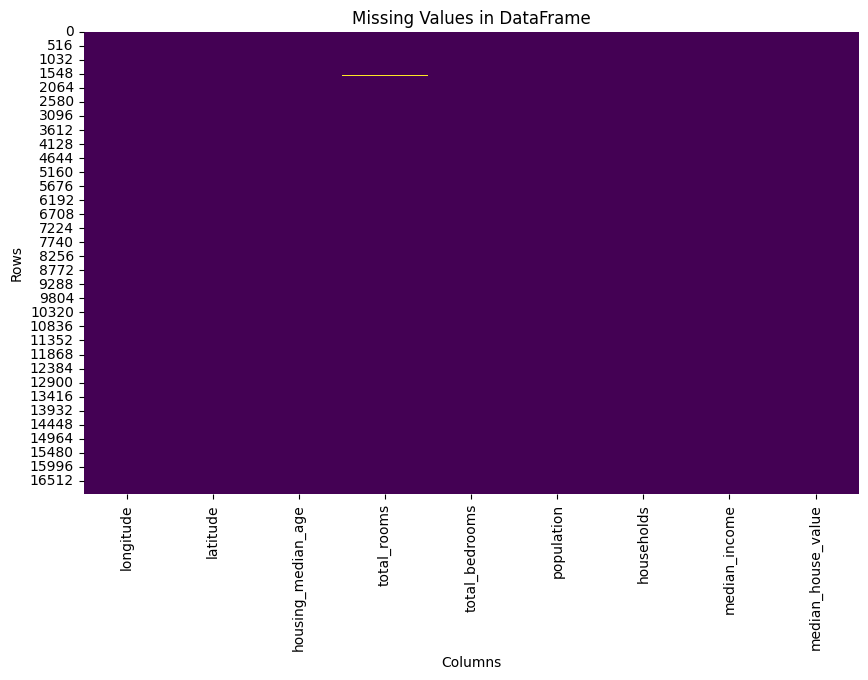

longitude             2
latitude              1
housing_median_age    2
total_rooms           3
total_bedrooms        4
population            2
households            0
median_income         5
median_house_value    1
dtype: int64

In [ ]:
# 결측치를 한눈에 그래프로 보여주기
# 일반적으로 heatmap으로 보여줌

plt.figure(figsize=(10, 6))
sns.heatmap(df_missing.isna(), cbar=False, cmap='viridis')
plt.title('Missing Values in DataFrame')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

df_missing.isna().sum()